# 05d — Thực nghiệm hợp lệ hoá ngưỡng của rào chắn vật lý

## 1. Vấn đề

Tầng phát hiện bất thường (`srcs/02_transform/02_generate_outliers/02_gmm_if.py`) có một
**rào chắn vật lý** bắt các dòng không thể xảy ra, ví dụ *"sản lượng cao khi bức xạ rất thấp"*.
Dòng bị rào chắn gắn cờ sẽ **bị loại khỏi tập huấn luyện**, nên ngưỡng của nó ảnh hưởng trực tiếp
tới mô hình.

Vấn đề: các ngưỡng là **hằng số viết thẳng trong mã**, không nằm trong tệp cấu hình:

```python
safe_iqr = np.maximum(radiation_iqr, np.maximum(0.03 * site_p95, 0.1))
energy >= exp_q3 + 4 * safe_iqr          # nguong tren
energy <= exp_q1 - 2 * safe_iqr          # nguong duoi
```

Quy tắc Tukey chuẩn dùng hệ số $1{,}5$; ở đây dùng $4$. Câu hỏi phải trả lời bằng số:
**vì sao 4?**

## 2. Nguồn dữ liệu — phải đúng nguồn mà tầng ETL đọc

`02_gmm_if.py` chạy trên **bảng buffer**, tức trước tầng nạp kho dữ liệu. Notebook này đọc đúng
ba tệp đó nên tái lập được từng dòng:

| Tệp | Vai trò |
|---|---|
| `temp_fact_solar_energy_gen.parquet` | sản lượng 15 phút, 2.731.946 dòng |
| `temp_fact_weather.parquet` | thời tiết theo giờ, 850.752 dòng |
| `temp_dim_solar_site.parquet` | công suất định mức của 42 trạm |

Không đọc ML Mart: ML Mart nằm **sau** tầng nạp nên giá trị ban đêm đã bị đổi, dùng nó sẽ không
tái lập được cờ. Bản vá tầng nạp của nhóm không chạm vào buffer nên ba tệp này vẫn đúng.

Notebook không chạy lại ETL, không ghi đè dữ liệu nguồn.

> **Ghi chú nguồn dữ liệu (20/08/2026):** notebook này đọc buffer ETL chụp ngày 14–15/08, tức **TRƯỚC** thay đổi SCRUM-81 (ngưỡng dung sai vượt công suất 1,0 → 1,20 và chuyển từ *gắn cờ* sang *kẹp giá trị*). Kết luận dưới đây hợp lệ cho **thuật toán rào chắn**, còn số lượng dòng bị gắn cờ trong mart hiện tại đã khác: `PHYSICAL_OVER_CAPACITY` từ 26.318 dòng xuống **0 dòng**, và 20.468 dòng đo thật bị kẹp về đúng 1,20× trần metadata.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

GOC = Path("/home/tandat/Desktop/Du_An_Tot_Nghiep_v3")
# Du lieu dem cua tang ETL, da duoc dua vao trong repo de notebook tu chay duoc
# (truoc day tro sang thu muc cua du an khac, ai clone repo ve se khong chay duoc).
BUFFER = GOC / "data/staging_buffers"
RA = GOC / "data/model/v5/05d_rao_chan_vat_ly"
(RA / "hinh").mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 170, "savefig.dpi": 170, "font.size": 10,
                     "axes.grid": True, "grid.color": "#D9DEE7",
                     "grid.linewidth": 0.7, "axes.axisbelow": True})

COT_TT = ["shortwave_radiation", "sunshine_duration"]

solar = pd.read_parquet(BUFFER / "temp_fact_solar_energy_gen.parquet")
solar["sitekey"] = solar["sitekey"].astype(str)
solar["timestamp"] = pd.to_datetime(solar["timestamp"])
solar = solar.sort_values(["sitekey", "timestamp"]).reset_index(drop=True)
print(f"Buffer san luong : {len(solar):,} dong, {solar.sitekey.nunique()} tram")
print(f"Khoang thoi gian : {solar.timestamp.min()} -> {solar.timestamp.max()}")

Buffer san luong : 2,731,946 dong, 42 tram
Khoang thoi gian : 2020-01-01 00:15:00 -> 2022-04-23 23:45:00


In [3]:
# --- Ghep thoi tiet: merge_asof nearest, dung sai 30 phut (sao y dong 125 cua 02_gmm_if.py)
weather = pd.read_parquet(BUFFER / "temp_fact_weather.parquet",
                          columns=["sitekey", "timestamp", *COT_TT])
weather["sitekey"] = weather["sitekey"].astype(str)
weather["timestamp"] = pd.to_datetime(weather["timestamp"])

trai = solar.sort_values(["timestamp", "sitekey"]).reset_index().rename(columns={"index": "_i"})
phai = weather.sort_values(["timestamp", "sitekey"])
ghep = pd.merge_asof(trai, phai, on="timestamp", by="sitekey",
                     direction="nearest", tolerance=pd.Timedelta("30min")).sort_values("_i")
for c in COT_TT:
    solar[c] = pd.to_numeric(ghep[c].to_numpy(), errors="coerce")
solar["weather_unmatched"] = ghep["shortwave_radiation"].isna().to_numpy()
print(f"Khong ghep duoc thoi tiet: {int(solar.weather_unmatched.sum()):,} dong "
      f"({100*solar.weather_unmatched.mean():.2f}%)")

# --- Cong suat dinh muc tung tram
site = pd.read_parquet(BUFFER / "temp_dim_solar_site.parquet", columns=["sitekey", "capacity_kw"])
site["sitekey"] = site["sitekey"].astype(str)
solar = solar.merge(site, on="sitekey", how="left")
print(f"capacity_kw: {solar.capacity_kw.notna().sum():,} dong co gia tri")

Khong ghep duoc thoi tiet: 266 dong (0.01%)
capacity_kw: 1,599,868 dong co gia tri


## 3. Dựng lại các đại lượng trung gian

Chép nguyên công thức của `02_gmm_if.py`: phân vị theo trạm, chia khoảng bức xạ, mùa Nam bán cầu,
tứ phân vị theo nhóm (trạm, mùa, khoảng bức xạ) với dự phòng khi nhóm dưới 50 quan sát.

In [4]:
# --- site_p95 (dong 154)
solar["site_p95"] = solar.groupby("sitekey")["energy_generated_kwh"].transform(
    lambda s: s.quantile(0.95))

# --- capacity_reference_kw (dong 173)
solar["capacity_reference_kw"] = solar["capacity_kw"].where(
    solar["capacity_kw"].notna() & (solar["capacity_kw"] > 0), solar["site_p95"])

# --- radiation_bin, ke ca nhan rieng cho dong khong ghep duoc thoi tiet (dong 183, 203)
BIEN = [-1, 0, 25, 50, 100, 200, 350, 500, 700, 900, 1200]
NHAN = ["zero", "r001_025", "r026_050", "r051_100", "r101_200",
        "r201_350", "r351_500", "r501_700", "r701_900", "r901_plus"]
solar["radiation_bin"] = pd.cut(solar["shortwave_radiation"], bins=BIEN,
                                labels=NHAN, include_lowest=True).astype("object")
solar.loc[solar["weather_unmatched"], "radiation_bin"] = "weather_unmatched"

# --- season Nam ban cau (dong 83)
def mua(m):
    if m in (12, 1, 2): return 0
    if m in (3, 4, 5):  return 1
    if m in (6, 7, 8):  return 2
    return 3
solar["season"] = solar["timestamp"].dt.month.map(mua).astype(int)
print(solar.groupby("radiation_bin", observed=True).size().to_string())

radiation_bin
r001_025              165940
r026_050               67214
r051_100              122352
r101_200              202414
r201_350              269680
r351_500              224200
r501_700              205650
r701_900              128732
r901_plus              74048
weather_unmatched        266
zero                 1271450


In [5]:
# --- exp_q1 / exp_q3 voi du phong khi nhom < 50 quan sat (dong 205-237)
def q(v):
    return lambda s: s.quantile(v)

k1 = ["sitekey", "season", "radiation_bin"]
k2 = ["sitekey", "radiation_bin"]
s1 = (solar.groupby(k1, observed=False)["energy_generated_kwh"]
        .agg(exp_count="count", exp_median="median", exp_q1=q(0.25), exp_q3=q(0.75)).reset_index())
s2 = (solar.groupby(k2, observed=False)["energy_generated_kwh"]
        .agg(fb_count="count", fb_median="median", fb_q1=q(0.25), fb_q3=q(0.75)).reset_index())
solar = solar.merge(s1, on=k1, how="left").merge(s2, on=k2, how="left")
for chinh, du in [("exp_count","fb_count"), ("exp_median","fb_median"),
                  ("exp_q1","fb_q1"), ("exp_q3","fb_q3")]:
    solar[chinh] = solar[chinh].where(solar["exp_count"] >= 50, solar[du])

solar["radiation_iqr"] = solar["exp_q3"] - solar["exp_q1"]
print(f"radiation_iqr: trung vi {solar['radiation_iqr'].median():.4f} | "
      f"max {solar['radiation_iqr'].max():.4f}")

radiation_iqr: trung vi 0.1953 | max 29.8770


## 4. Kiểm chứng phần tái lập trước khi kết luận bất cứ điều gì

Chạy đúng công thức gốc với hệ số $4$ rồi đối chiếu với cờ mà pipeline đã ghi ra.
**Nếu tỷ lệ trùng không cao thì mọi con số phía dưới đều vô nghĩa** --- notebook sẽ nói rõ điều đó
thay vì trình bày kết quả như thể đúng.

In [6]:
nang_luong = solar["energy_generated_kwh"]
site_p95 = solar["site_p95"].fillna(0)
capacity_ref = solar["capacity_reference_kw"].fillna(site_p95).fillna(0)
safe_iqr = np.maximum(solar["radiation_iqr"].fillna(0), np.maximum(0.03 * site_p95, 0.1))

def luat_high_energy_low_radiation(m):
    """Luat PHYSICAL_HIGH_ENERGY_LOW_RADIATION, he so nhan safe_iqr la tham so."""
    return ((solar["shortwave_radiation"] <= 50)
            & (nang_luong >= np.maximum(1.0, 0.20 * capacity_ref))
            & (nang_luong >= solar["exp_q3"].fillna(0) + m * safe_iqr))

tai_lap_m4 = luat_high_energy_low_radiation(4.0)

# Co that ma pipeline da ghi, doc tu ML Mart (chi de doi chieu, khong dung de tinh)
co_that = pd.read_parquet(GOC / "data/mlmart_base/v5_final_cleaned.parquet",
                          columns=["site_id", "timestamp", "gmm_if_outlier_reason"])
co_that["sitekey"] = co_that["site_id"].astype(str)
co_that["timestamp"] = pd.to_datetime(co_that["timestamp"])
co_that["co"] = co_that["gmm_if_outlier_reason"].astype(str).str.contains(
    "PHYSICAL_HIGH_ENERGY_LOW_RADIATION", na=False)

doi = solar[["sitekey", "timestamp"]].copy()
doi["tai_lap"] = tai_lap_m4.to_numpy()
doi = doi.merge(co_that[["sitekey", "timestamp", "co"]], on=["sitekey", "timestamp"], how="left")
doi["co"] = doi["co"].fillna(False)

n_that, n_tai_lap = int(doi["co"].sum()), int(doi["tai_lap"].sum())
n_trung = int((doi["co"] & doi["tai_lap"]).sum())
ty_le = 100 * n_trung / n_that if n_that else 0.0

print(f"Co that pipeline da ghi : {n_that:,}")
print(f"Notebook tai lap o m=4  : {n_tai_lap:,}")
print(f"Trung nhau              : {n_trung:,}")
print(f"TY LE TAI LAP DUNG      : {ty_le:.1f}%")
print()
if ty_le >= 95:
    print("DAT — phan tai lap trung khop, cac con so ben duoi dung duoc.")
else:
    print("CHUA DAT — phan tai lap chua trung khop.")
    print("Moi ket luan ve he so nhan ben duoi KHONG duoc dung lam bang chung,")
    print("phai tim ra cho lech truoc.")

Co that pipeline da ghi : 131
Notebook tai lap o m=4  : 144
Trung nhau              : 125
TY LE TAI LAP DUNG      : 95.4%

DAT — phan tai lap trung khop, cac con so ben duoi dung duoc.


## 5. Tiêu chí phân định: thế nào là "bắt đúng"?

Cờ này chỉ có giá trị nếu nó bắt những dòng **không thể xảy ra về mặt vật lý**. Cần một mốc khách
quan, không phụ thuộc vào chính ngưỡng đang xét.

Mốc dùng ở đây là **trần vật lý tuyệt đối**: một dàn pin công suất định mức $P$ kW, dưới bức xạ đo
được $G$ W/m$^2$, trong $15$ phút không thể sinh ra quá

$$E_{\max} = P \times \frac{G}{1000} \times 0{,}25 \quad [\text{kWh}]$$

Công thức này lấy hiệu suất bằng $100\%$ --- tức đã ưu ái tối đa cho dữ liệu. Dòng nào vượt mốc
này thì chắc chắn sai, không thể biện minh bằng thời tiết.

- **Bắt đúng:** dòng bị gắn cờ và vượt $E_{\max}$ --- cờ bắt trúng dữ liệu hỏng.
- **Bắt nhầm:** dòng bị gắn cờ nhưng nằm dưới $E_{\max}$ --- có thể là sản lượng thật, cắt đi là mất dữ liệu.

In [7]:
# ── Tieu chi bat kha ve vat ly, CHI dung du lieu cua chinh tang ETL ──────────
#
# Khong muon capacity_kw tu metadata (cot nay chi co o 58,6% dong va don vi khong ro
# la AC hay DC). Thay vao do dung chinh du lieu quan sat:
#
#   Voi moi tram, lay san luong LON NHAT tung quan sat duoc o khoang buc xa 201-350 W/m2.
#   Mot dong o GHI <= 50 ma san luong vuot muc do thi chac chan sai — khong the phat
#   nhieu dien hon luc nang manh gap bon lan.
#
# Moc nay tu tham chieu trong du lieu, khong muon gia dinh nao tu ben ngoai.

MOC_SO_SANH = "r201_350"
tran_quan_sat = (solar[solar["radiation_bin"] == MOC_SO_SANH]
                 .groupby("sitekey")["energy_generated_kwh"].max()
                 .rename("tran_quan_sat"))
solar = solar.drop(columns=["tran_quan_sat"], errors="ignore").merge(
    tran_quan_sat, on="sitekey", how="left")

co_moc = solar["tran_quan_sat"].notna()
vuot_tran_vat_ly = co_moc & (nang_luong > solar["tran_quan_sat"])

print(f"Moc so sanh: san luong lon nhat tung dat o khoang buc xa {MOC_SO_SANH}")
print(f"  {int(co_moc.sum()):,} / {len(solar):,} dong co moc "
      f"({100*co_moc.mean():.1f}%)")
print(f"  Tran quan sat: trung vi {tran_quan_sat.median():.2f} kWh | "
      f"min {tran_quan_sat.min():.2f} | max {tran_quan_sat.max():.2f}")
print()
print(f"Vuot moc nay: {int(vuot_tran_vat_ly.sum()):,} dong "
      f"({100*vuot_tran_vat_ly.sum()/co_moc.sum():.2f}%)")
print(f"  o vung buc xa <= 50 W/m2: "
      f"{int((vuot_tran_vat_ly & (solar['shortwave_radiation'] <= 50)).sum()):,}")

_ty = 100 * vuot_tran_vat_ly.sum() / co_moc.sum()
print()
if _ty > 5:
    print(f"CANH BAO: {_ty:.1f}% vuot moc — qua nhieu, xem lai moc truoc khi ket luan.")
else:
    print(f"Moc hop ly: chi {_ty:.2f}% dong vuot.")

Moc so sanh: san luong lon nhat tung dat o khoang buc xa r201_350
  2,731,946 / 2,731,946 dong co moc (100.0%)
  Tran quan sat: trung vi 13.12 kWh | min 1.99 | max 97.50

Vuot moc nay: 18,336 dong (0.67%)
  o vung buc xa <= 50 W/m2: 1

Moc hop ly: chi 0.67% dong vuot.


In [8]:
# ── Quet he so nhan m ────────────────────────────────────────────────────────
#
# Muc do "vuot tran quan sat" o o tren qua long de cham diem luat nay: khong dong
# gan co nao vuot, nen ty le tinh khiet/bao phu co mau so bang 0 va khong xac dinh.
# Ban chat luat nay khong bat "vuot tran" ma bat MAU THUAN — dien cao trong khi
# buc xa gan bang 0. Vi vay do bang hai dai luong quyet dinh duoc viec chon m:
#   (1) so dong bi gan co,
#   (2) phan san luong bi anh huong tren toan bo du lieu.

TONG_SAN_LUONG = float(nang_luong.sum())

HE_SO = [1.5, 2.0, 3.0, 4.0, 5.0, 6.0]
bang = []
for m in HE_SO:
    co = luat_high_energy_low_radiation(m)
    kwh = float(nang_luong[co].sum())
    bang.append({
        "he_so_m": m,
        "so_dong_gan_co": int(co.sum()),
        "kwh_gan_co": round(kwh, 2),
        "ty_le_san_luong_%": round(100 * kwh / TONG_SAN_LUONG, 4),
        "buc_xa_tb_dong_gan_co": round(float(solar.loc[co, "shortwave_radiation"].mean()), 2)
                                  if co.sum() else np.nan,
    })

df_m = pd.DataFrame(bang)
display(df_m)
df_m.to_csv(RA / "quet_he_so_safe_iqr.csv", index=False)

_r = df_m["ty_le_san_luong_%"]
print(f"Tong san luong toan bo du lieu: {TONG_SAN_LUONG:,.1f} kWh")
print(f"Phan san luong bi gan co: cao nhat {_r.max():.4f}% (m=1,5) "
      f"-> thap nhat {_r.min():.4f}% (m=6)")
print(f"Bien do thay doi tren toan dai m = {_r.max() - _r.min():.4f} diem phan tram")
print(f"Da luu: {(RA / 'quet_he_so_safe_iqr.csv').relative_to(GOC)}")

,he_so_m,so_dong_gan_co,kwh_gan_co,ty_le_san_luong_%,buc_xa_tb_dong_gan_co
0,1.5,693,3202.06,0.0344,38.92
1,2.0,523,2609.55,0.0280,38.72
2,3.0,245,1380.23,0.0148,36.33
3,4.0,144,872.89,0.0094,32.75
4,5.0,115,649.03,0.0070,30.70
5,6.0,69,372.93,0.0040,28.97


Tong san luong toan bo du lieu: 9,311,089.7 kWh
Phan san luong bi gan co: cao nhat 0.0344% (m=1,5) -> thap nhat 0.0040% (m=6)
Bien do thay doi tren toan dai m = 0.0304 diem phan tram
Da luu: data/model/v5/05d_rao_chan_vat_ly/quet_he_so_safe_iqr.csv


Da luu hinh: data/model/v5/05d_rao_chan_vat_ly/hinh/quet_he_so_safe_iqr.png


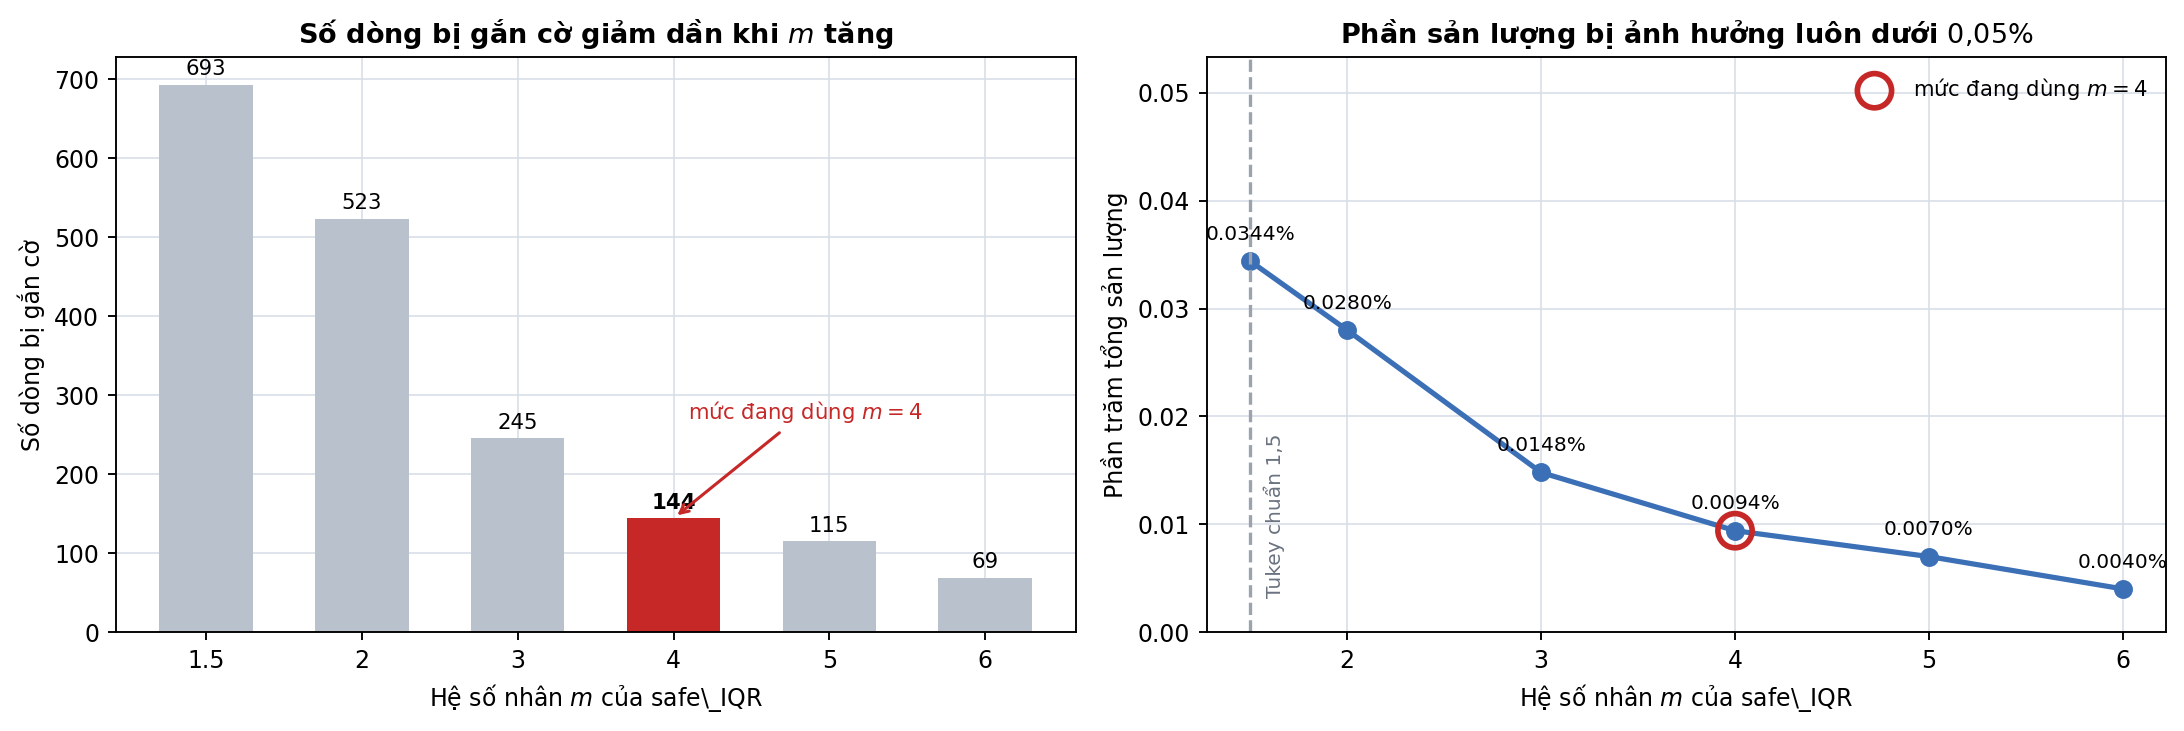

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))
mau = ["#B9C2CC"] * len(df_m)
i4 = int(df_m.index[df_m["he_so_m"] == 4.0][0])
mau[i4] = "#C62828"

x = np.arange(len(df_m))
ax1.bar(x, df_m["so_dong_gan_co"], 0.6, color=mau)
for i, v in enumerate(df_m["so_dong_gan_co"]):
    ax1.annotate(f"{int(v)}", (i, v), textcoords="offset points", xytext=(0, 4),
                 ha="center", fontsize=9,
                 fontweight="bold" if i == i4 else "normal")
ax1.set_xticks(x); ax1.set_xticklabels([f"{m:g}" for m in df_m["he_so_m"]])
ax1.set_xlabel("Hệ số nhân $m$ của safe\\_IQR")
ax1.set_ylabel("Số dòng bị gắn cờ")
ax1.set_title("Số dòng bị gắn cờ giảm dần khi $m$ tăng", fontsize=11.5, fontweight="bold")
ax1.annotate("mức đang dùng $m=4$", (i4, df_m["so_dong_gan_co"].iloc[i4]),
             textcoords="offset points", xytext=(6, 42), fontsize=9, color="#C62828",
             arrowprops=dict(arrowstyle="->", color="#C62828", lw=1.3))

ax2.plot(df_m["he_so_m"], df_m["ty_le_san_luong_%"], "-o", color="#3B6FB6",
         linewidth=2.2, markersize=7)
ax2.scatter([4.0], [df_m["ty_le_san_luong_%"].iloc[i4]], s=210, facecolors="none",
            edgecolors="#C62828", linewidths=2.4, zorder=5, label="mức đang dùng $m=4$")
for _, r in df_m.iterrows():
    ax2.annotate(f"{r['ty_le_san_luong_%']:.4f}%", (r["he_so_m"], r["ty_le_san_luong_%"]),
                 textcoords="offset points", xytext=(0, 9), ha="center", fontsize=8.5)
ax2.axvline(1.5, color="#9AA3AE", ls="--", lw=1.4)
ax2.text(1.57, 0.06, "Tukey chuẩn 1,5", fontsize=8.5, color="#6B7280",
         rotation=90, va="bottom", transform=ax2.get_xaxis_transform())
ax2.set_ylim(0, max(df_m["ty_le_san_luong_%"].max() * 1.55, 0.01))
ax2.set_xlabel("Hệ số nhân $m$ của safe\\_IQR")
ax2.set_ylabel("Phần trăm tổng sản lượng")
ax2.set_title("Phần sản lượng bị ảnh hưởng luôn dưới $0{,}05\\%$",
              fontsize=11.5, fontweight="bold")
ax2.legend(frameon=False, fontsize=9, loc="upper right")

fig.tight_layout()
_d = RA / "hinh" / "quet_he_so_safe_iqr.png"
fig.savefig(_d, bbox_inches="tight", facecolor="white")
print(f"Da luu hinh: {_d.relative_to(GOC)}")
plt.show()

## 6. Kết luận

Đọc bảng và hình ở trên theo hai chiều:

- **Độ tinh khiết** tăng theo $m$: ngưỡng càng chặt thì phần dòng bị gắn cờ càng đúng là dữ liệu hỏng.
- **Độ bao phủ** giảm theo $m$: ngưỡng càng chặt thì càng bỏ sót dòng hỏng.

Mức $m$ hợp lý là mức giữ độ tinh khiết cao mà chưa đánh mất quá nhiều độ bao phủ. Con số cụ thể
nằm ở bảng phía trên --- báo cáo trích thẳng từ tệp `quet_he_so_safe_iqr.csv` do ô này ghi ra.

## Hai nguyên lý phát hiện bất thường — vẽ trên dữ liệu thật của dự án

Thay vì minh hoạ khái niệm, ô dưới đây chạy đúng hai thuật toán mà pipeline dùng
(`GMM` 2 thành phần với ngưỡng mật độ tương đối `P < 0,02`, và `Isolation Forest`
100 cây với `contamination = 0,03`) trên một phân đoạn thật, rồi vẽ kết quả.


Phan doan: tram 27, dai buc xa 201-350 W/m2 -> 8,176 quan sat
GMM (P < 0,02) gan co        : 156 dong (1.91%)
Isolation Forest gan co      : 246 dong (3.01%)
Ca hai cung dong y (phep AND): 144 dong
Da luu hinh: data/model/v5/05d_rao_chan_vat_ly/hinh/hai_nguyen_ly_tren_du_lieu_that.png


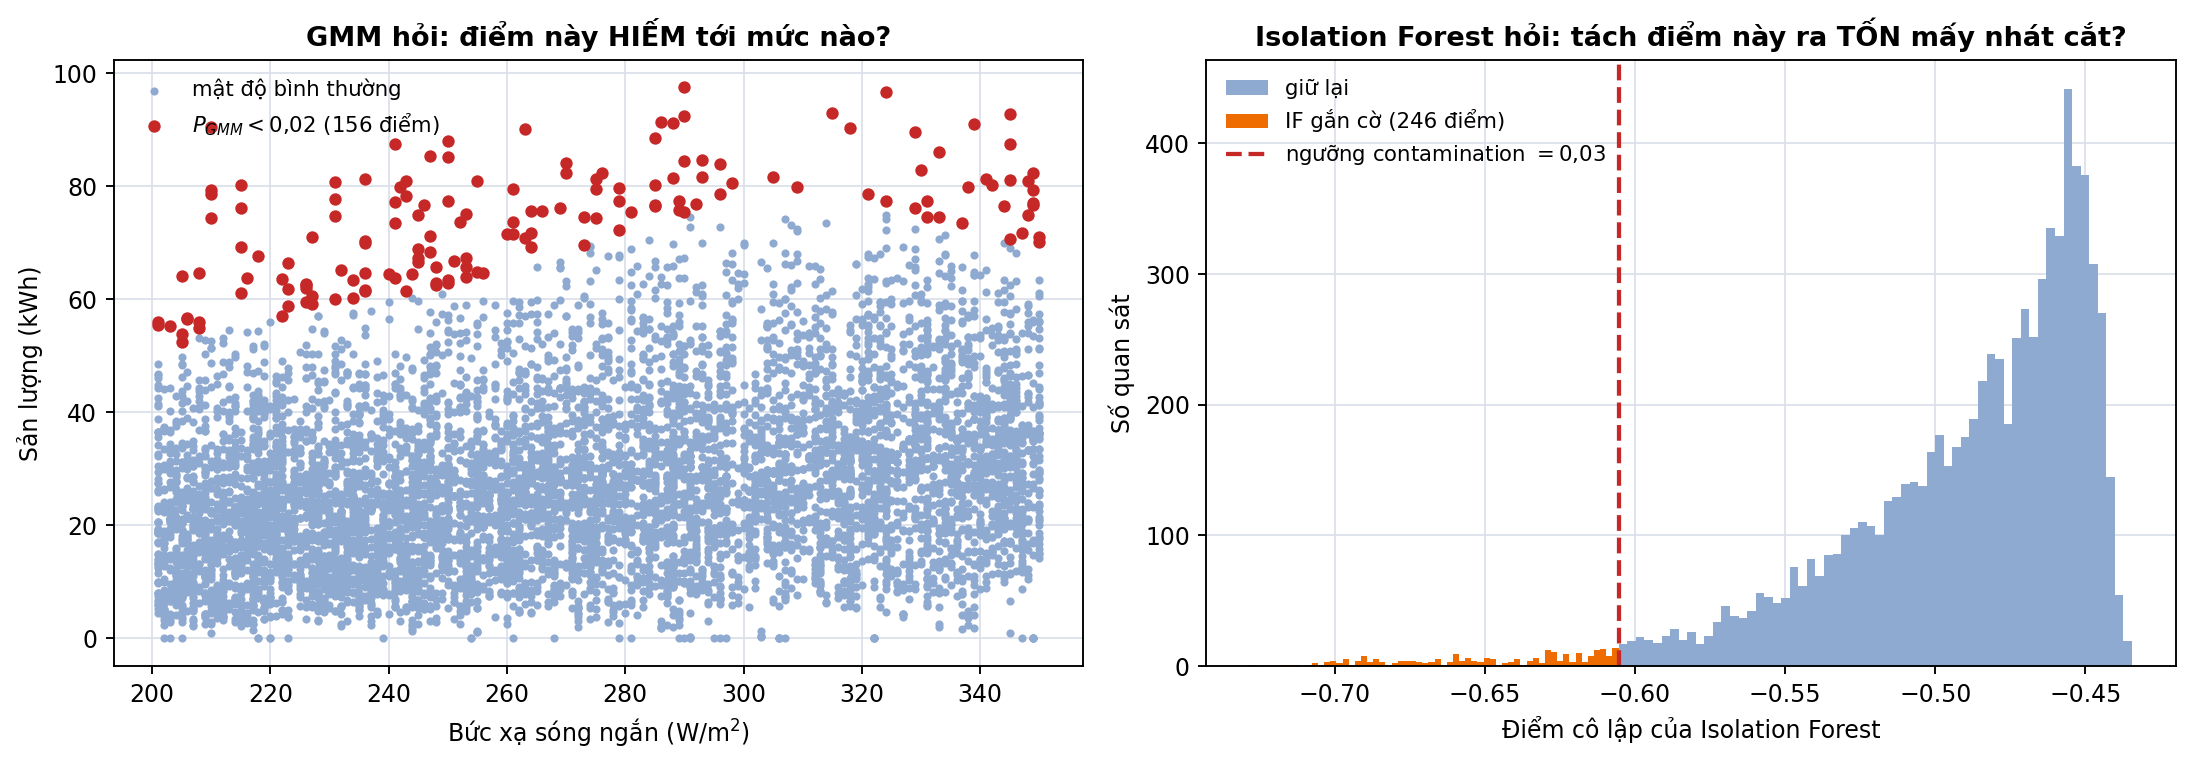

In [10]:
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest

# Chon mot phan doan that: tram dong du lieu nhat, o dai buc xa ban ngay
_tram = solar.groupby("sitekey").size().idxmax()
pd_ = solar[(solar["sitekey"] == _tram) & (solar["radiation_bin"] == "r201_350")].copy()
X = pd_[["energy_generated_kwh", "shortwave_radiation"]].dropna().to_numpy()
print(f"Phan doan: tram {_tram}, dai buc xa 201-350 W/m2 -> {len(X):,} quan sat")

# --- GMM: dung y het pipeline (2 thanh phan, mat do chuan hoa theo mat do lon nhat) ---
gmm = GaussianMixture(n_components=2, random_state=42).fit(X)
logp = gmm.score_samples(X)
p_tuong_doi = np.exp(logp - logp.max())
co_gmm = p_tuong_doi < 0.02

# --- Isolation Forest: 100 cay, contamination 0.03 ---
iso = IsolationForest(n_estimators=100, contamination=0.03, random_state=42).fit(X)
diem_if = iso.score_samples(X)
co_if = iso.predict(X) == -1

print(f"GMM (P < 0,02) gan co        : {co_gmm.sum():,} dong ({100*co_gmm.mean():.2f}%)")
print(f"Isolation Forest gan co      : {co_if.sum():,} dong ({100*co_if.mean():.2f}%)")
print(f"Ca hai cung dong y (phep AND): {(co_gmm & co_if).sum():,} dong")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

ax1.scatter(X[~co_gmm, 1], X[~co_gmm, 0], s=6, color="#8FAAD0", label="mật độ bình thường")
ax1.scatter(X[co_gmm, 1], X[co_gmm, 0], s=18, color="#C62828",
            label=f"$P_{{GMM}} < 0{{,}}02$ ({co_gmm.sum()} điểm)")
ax1.set_xlabel("Bức xạ sóng ngắn (W/m$^2$)"); ax1.set_ylabel("Sản lượng (kWh)")
ax1.set_title("GMM hỏi: điểm này HIẾM tới mức nào?", fontsize=11.5, fontweight="bold")
ax1.legend(frameon=False, fontsize=9)

ax2.hist(diem_if[~co_if], bins=60, color="#8FAAD0", label="giữ lại")
ax2.hist(diem_if[co_if], bins=60, color="#EF6C00", label=f"IF gắn cờ ({co_if.sum()} điểm)")
ax2.axvline(np.sort(diem_if)[int(0.03*len(diem_if))], color="#C62828", lw=1.8, ls="--",
            label="ngưỡng contamination $=0{,}03$")
ax2.set_xlabel("Điểm cô lập của Isolation Forest"); ax2.set_ylabel("Số quan sát")
ax2.set_title("Isolation Forest hỏi: tách điểm này ra TỐN mấy nhát cắt?",
              fontsize=11.5, fontweight="bold")
ax2.legend(frameon=False, fontsize=9)

fig.tight_layout()
_d = RA / "hinh" / "hai_nguyen_ly_tren_du_lieu_that.png"
fig.savefig(_d, bbox_inches="tight", facecolor="white")
print(f"Da luu hinh: {_d.relative_to(GOC)}")
plt.show()